# Exploratory Data Analysis - EDA

The goal of eda is to explore the dataset and identify patterns, relations between variables, and potential factors that influence students performance. 

The focus is to answer the key questions such as:
- What factors are associated with higher exam scores?
- Do demographic or socio-economic variables impact performance?
- Which features might be useful for predicitons?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

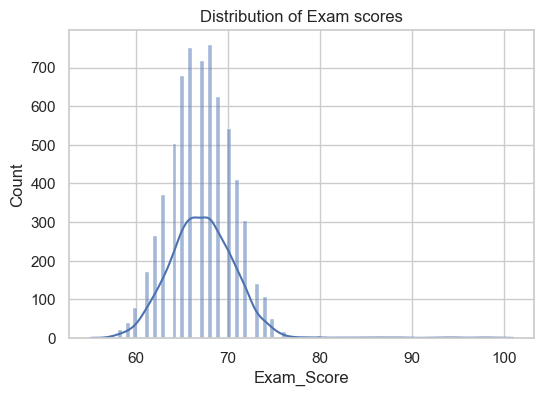

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["Exam_Score"], kde = True)
plt.title("Distribution of Exam scores")
plt.show()

The first graph shows the distribution of the target variable, Exam Score.

This helps understand the overall performance of the students and detect certain trends.

In [16]:
df["Exam_Score"].value_counts().sort_index()

Exam_Score
55       1
56       1
57       4
58      22
59      40
60      77
61     171
62     264
63     371
64     501
65     679
66     751
67     717
68     759
69     624
70     542
71     408
72     304
73     141
74     106
75      48
76      16
77       5
78       4
79       3
80       5
82       4
83       1
84       3
85       1
86       4
87       2
88       3
89       3
91       1
92       2
93       2
94       4
95       2
96       1
97       3
98       3
99       2
100      1
101      1
Name: count, dtype: int64

In addition to the histogram, the exact number of students for each exam score was added. This provides a more detailed view of the distribution, especially for the less frequent scores that are lost and not visible in the histogram.

In [17]:
#df[df["Exam_Score"] > 100]   # there is only one signulare exam_score higher than 100, most likely a mistake

df = df[df["Exam_Score"] <= 100]

Most students cluster around scores between 65 and 70, forming a near-normal distribution.

Interestingly, low scores are nonexistant and extremely high scores are very rare, suggesting that student performance is relatively consistent across the dataset.

This indicates that small factors, sucha as study habits and preparations, might be the key differetiators between average and very high performing students.

One score above 100 was identified, which is most likely a data entry or a measurement error and therefor removed from the dataset.


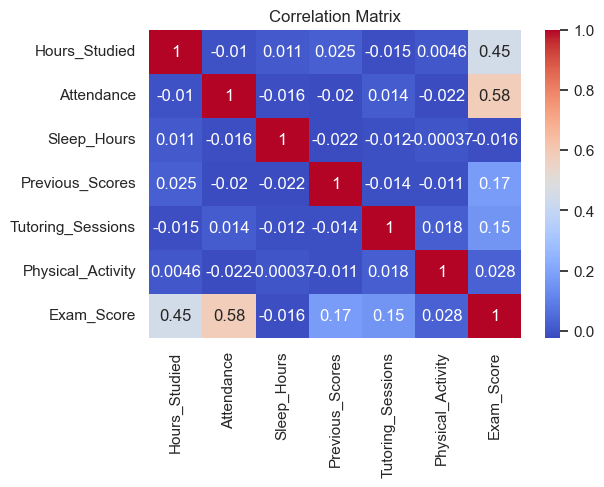

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows the relationships between different numerical variables.

Among all features, Attendance has the strongest positive correlation with exam score - 0.58. This suggest that consistant attendance is a key factor in receiving higher exam scores.

The second feature with a high correlation with exam score is Hours_Studied - 0.45. Both of these features are key factors associated with higher exam scores by a great margain. 

Other variables, such as Previous_Scores and Tutoring_Sessions with respectively 0.17 and 0.15 correlation with Exam_Score, show weaker positive relationships, indicating a more limited impact on the overall performance.

Interestingly, Sleep_Hours and Physcial_Activity show little to no correlation with Exam_Score, suggesting that their influence may not be directly captured with linear correlation. 

Overall, the results indicate that while some academic-related factors show great impact on performance, many variables have weak linear relationship with exam outcomes. This highlights the importance of further and more complex analysis, particularly for categorical variables, which cannot be included in correlation matrix, and potential non-linear effects. 

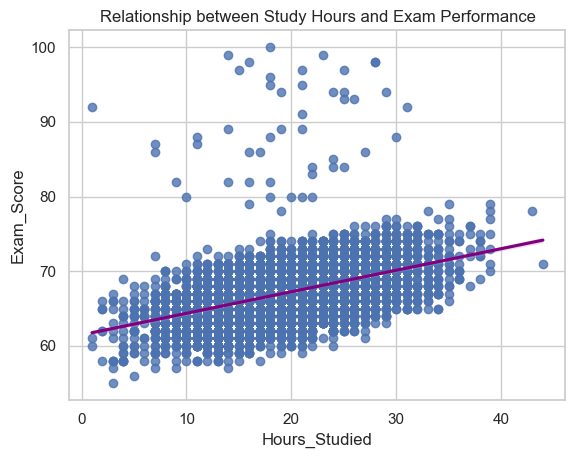

In [39]:
sns.regplot(x="Hours_Studied", y="Exam_Score", data = df, line_kws={"color" : "purple"})
plt.title("Relationship between Study Hours and Exam Performance")
plt.show()

The scatterplot shows a clear positive relationship between the amount of hours spend on studying and exam scores. Students who spend more time studying tend to achive higher results. 

Interestingly, the highest scores are often observed in the range of 10 - 30 study hours. This suggest that, while studying increased study time generally improves results, there are still other factors like motivation, teaching quality, focus or students' capabilites that play a significant role in determining final results.

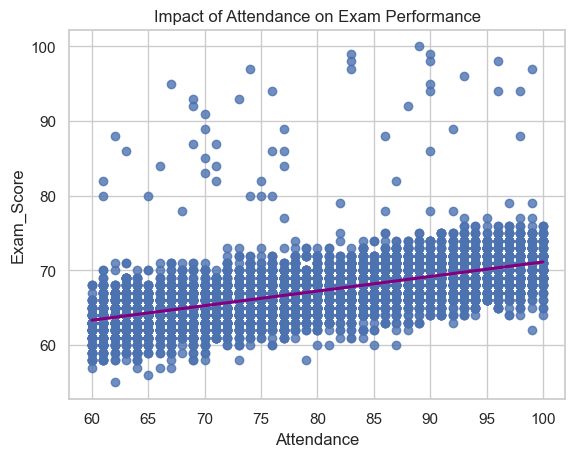

In [40]:
sns.regplot(x="Attendance", y="Exam_Score", data = df, line_kws={"color" : "purple"})
plt.title("Impact of Attendance on Exam Performance")
plt.show()

A strong positive relationship can be observed between attendance and exam scores, similarly to the results of correlation matrix.

Students who have higher attendance, tend to consistently achieve better results. Compared to study hours, attendance shows a more stable and consistant trend.

---

In [21]:
df.groupby("Gender")["Exam_Score"].agg(["mean", "median"])

,mean,median
Gender,,
Female,67.232808,67.0
Male,67.228894,67.0


In [22]:
df.groupby("Parental_Education_Level")["Exam_Score"].agg(["mean", "median"])

,mean,median
Parental_Education_Level,,
College,67.315737,67.0
High School,66.887681,67.0
Postgraduate,67.970881,68.0


In [23]:
df.groupby("Parental_Involvement")["Exam_Score"].agg(["mean", "median"])

,mean,median
Parental_Involvement,,
High,68.092767,68.0
Low,66.332335,66.0
Medium,67.098156,67.0


In [24]:
df.groupby("Family_Income")["Exam_Score"].agg(["mean", "median"])

,mean,median
Family_Income,,
High,67.816246,68.0
Low,66.848428,67.0
Medium,67.334959,67.0


In [25]:
df.groupby("Distance_from_Home")["Exam_Score"].agg(["mean", "median"])

,mean,median
Distance_from_Home,,
Far,66.457447,66.0
Moderate,66.964447,67.0
Near,67.493799,67.0


Both mean and median are used to compare exam scores across chosen groups. The median provides a more robust measure, as it is less sensitive to extreme values. This allows for a more reliable comparison of performance between categories.

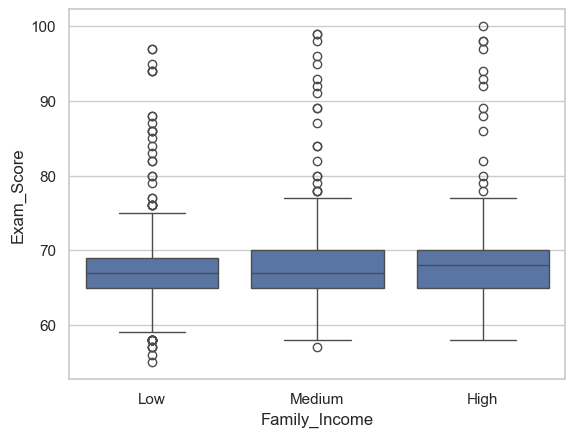

In [26]:
sns.boxplot(x="Family_Income", y="Exam_Score", data=df)
plt.show()

In [42]:
q3 = df["Exam_Score"].quantile(0.75)

df.loc[:,"is_High"] = df["Exam_Score"] >= q3

df[df["is_High"]]["Family_Income"].value_counts()

Family_Income
Medium    915
Low       817
High      516
Name: count, dtype: int64

In [31]:

df.groupby("Family_Income")["is_High"].mean() * 100

Family_Income
High      40.694006
Low       30.576347
Medium    34.321080
Name: is_High, dtype: float64

Students from the high-income backgrounds have the highest share of top performers (~40.7%), followed by medium and low income groups. This indicates clear upward trend, a higher income is associated with a greater likelihood of achieving higher exam scores. This may reflect differences in access to educational resources, support and learning environments.

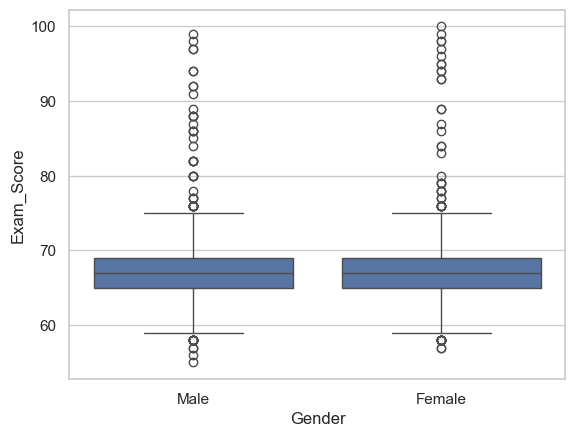

In [32]:
sns.boxplot(x="Gender", y="Exam_Score", data=df)
plt.show()

In [33]:
df[df["is_High"]]["Gender"].value_counts()

Gender
Male      1314
Female     934
Name: count, dtype: int64

In [34]:
df.groupby("Gender")["is_High"].mean() * 100

Gender
Female    33.452722
Male      34.452019
Name: is_High, dtype: float64

The proportion of top-performing students is very similar between genders, ~33.5% for women and ~34.5% for men. This suggest that gender does not play a very siginificant role in determining high academic performance in this dataset. 

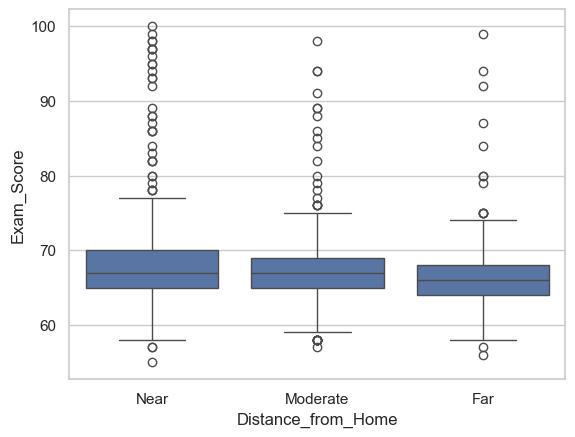

In [35]:
sns.boxplot(x="Distance_from_Home", y="Exam_Score", data=df)
plt.show()

In [36]:
df[df["is_High"]]["Distance_from_Home"].value_counts()

Distance_from_Home
Near        1462
Moderate     625
Far          161
Name: count, dtype: int64

In [37]:
df.groupby("Distance_from_Home")["is_High"].mean() * 100

Distance_from_Home
Far         24.468085
Moderate    31.296945
Near        37.003290
Name: is_High, dtype: float64

Students' distance from home plays a significant role in exam results. Students living closer to school have higher percentage of top performencers ~37% compared to a moderate (~31.3%) and far distance (~24.5%). 

This suggest that proximity to school may positively influence academic performance, possibly because of reduced commuting time, lowe fatique and better acces to school related resources.

The analysis of categorical variables show that socio-economic and environmental factors appear to have a strong impact on students performance.

Income levels show a clear relationship with performance, with higher-income studnets being more likely to be top performers. Distance from school also plays a role, with students living closer to the schools achieving better results. In contrast, gender shows little to no meaningful difference in performance outcomes.

Overall, these findings suggest that access to resources and external conditions may be driving forces in achieving higher exam scores.

---


# Summary

The exploratory data analysis reveals several key factors influencing student performance.

Academic engagmenet, particurarly attendance and study time, shows strongest relationship with exam scores. Students who attend classes regularly and dedicade more time to studying tend to achieve better results. 

In addition, socio-economic and environmental factors such as family income or distance from school also appear to play a meaningful role. Students from higher-income households and those living closer to school are more likely to be among the top performers. 

Overall, the results indicate that students success is driven by combination of efforts, study habits and access to resources, rather than one single dominant factor.